In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import random
from sklearn.metrics import r2_score 

In [3]:
from src.dominick import DominickDataLoader
from src.dominick.multiproduct_builder import MultiProductBuilder
from src.nn.data import ColumnEncoder, DataLoaderFactory, SplineBuilder
from src.nn.spline import MultiCubicSplineBasis
from src.nn.models import IntegrableDemandHead, ICDN
from src.nn.loss import ElasticityLoss
from src.multiproduct import MultiProductDataset, MultiProductContextEmbeddings

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Ajustes

In [5]:
# ── Datos ──────────────────────────────────────────────────────────
N_UPCS        = 5
N_KNOTS       = 16
TRAIN_FRAC    = 0.8
SMOOTH_WINDOW = 8          # ventana causal para y_smooth (Fase 0)

# ── Prior de elasticidad (EDA pooling log-log) ─────────────────────
BETA_EDA = -2           # se usará para init en Fase 0

# ── Arquitectura (compartida por las 3 fases) ──────────────────────
HIDDEN       = (64, 32, 16)
ACT          = "gelu"
DROPOUT      = 0.116019
D_STORE      = 16

# ── Entrenamiento por fase ─────────────────────────────────────────
BATCH_SIZE   = 32
N_EPOCHS_P0  = 350
N_EPOCHS_P1  = 350
N_EPOCHS_P2  = 400
LR_P0        = 0.000274
LR_P1        = 0.000017       # más bajo para no romper warm-start
LR_P2        = 0.000215
PATIENCE     = 30
ES_PATIENCE  = 70         # early stopping
LAMBDA_SMOOTH_P2 = 0.000022
LAMBDA_POS_P2    = 0.187591

# ── Checkpoints ────────────────────────────────────────────────────
CKPT_DIR = Path("../results/checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_P0  = CKPT_DIR / "phase0_best.pt"
CKPT_P1  = CKPT_DIR / "phase1_best.pt"
CKPT_P2  = CKPT_DIR / "phase2_best.pt"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


# Cargar y Preparar Datos

In [6]:
loader = DominickDataLoader()
df = loader.load("elasticity_dataset.csv")
print(f"Dataset shape: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")

Dataset shape: (463722, 30)
Columnas: ['store_code', 'upc_code', 'category_code', 'week_id', 'log_liters_sold', 'log_price_per_liter', 'on_promo', 'week_rank', 'sin_52', 'cos_52', 'sin_26', 'cos_26', 'sin_13', 'cos_13', 'weeks_since_first_seen_upc', 'weeks_since_first_seen_store_upc', 'liters_per_upc', 'lag_1_log_liters_sold', 'lag_2_log_liters_sold', 'lag_4_log_liters_sold', 'rolling_mean_4_log_liters_sold', 'rolling_mean_8_log_liters_sold', 'rolling_mean_13_log_liters_sold', 'miss_lag_1', 'miss_lag_2', 'miss_lag_4', 'miss_roll_4', 'miss_roll_8', 'miss_roll_13', 'promo_intensity_store_week']


# Factorizar colmnas Categóricas

In [7]:
encoder = ColumnEncoder()
_, store_cats = encoder.factorize(df, "store_code", sort=True)
_, week_cats  = encoder.factorize(df, "week_id",    sort=True)

n_stores = len(store_cats)
n_weeks  = len(week_cats)
print(f"Tiendas: {n_stores}  |  Semanas: {n_weeks}")

Tiendas: 70  |  Semanas: 302


# Split temporal y pipeline multi-producto

In [8]:
sorted_weeks   = sorted(df["week_id"].unique())
week_threshold = sorted_weeks[int(len(sorted_weeks) * TRAIN_FRAC)]
train_df_raw   = df[df["week_id"] < week_threshold].copy()

mp_builder = MultiProductBuilder()
mp_builder.fit(df, n_upcs=N_UPCS)
full_wide  = mp_builder.transform(df)
train_wide = full_wide[full_wide["week_id"] < week_threshold].copy()
val_wide   = full_wide[full_wide["week_id"] >= week_threshold].copy()
n_upcs     = mp_builder.n

store_map = {v: i for i, v in enumerate(store_cats)}
week_map  = {v: i for i, v in enumerate(week_cats)}
for w in [train_wide, val_wide]:
    w["store_code"] = w["store_code"].map(store_map)
    w["week_id"]    = w["week_id"].map(week_map)

print(f"Train: {len(train_wide):,}  |  Val: {len(val_wide):,}")
print(f"UPCs seleccionados: {n_upcs}")
print(f"Top {N_UPCS}: {mp_builder.selected_upcs[:N_UPCS]}")

Train: 15,822  |  Val: 3,986
UPCs seleccionados: 5
Top 5: [3410010505, 7289000011, 1820000784, 8248812345, 3410017306]


# Suavizado causal para Fase 0

In [9]:
train_wide_s = train_wide.sort_values(["store_code", "week_id"]).copy()
val_wide_s   = val_wide.sort_values(["store_code", "week_id"]).copy()

for i in range(n_upcs):
    col = f"log_liters_{i}"
    for df_w in [train_wide_s, val_wide_s]:
        df_w[col] = (
            df_w.groupby("store_code")[col]
            .transform(lambda s: s.rolling(window=SMOOTH_WINDOW, min_periods=1).mean())
        )

# train_wide_s y val_wide_s ahora tienen y_smooth en log_liters_i
print(f"y_smooth construido (ventana={SMOOTH_WINDOW}, causal)")

y_smooth construido (ventana=8, causal)


# Datasets y DataLoaders

In [10]:
loader_factory = DataLoaderFactory(num_workers=0, pin_memory=True)

# Fase 0: y_smooth
train_ds_p0 = MultiProductDataset(train_wide_s, n=n_upcs)
val_ds_p0   = MultiProductDataset(val_wide_s,   n=n_upcs)
train_loader_p0 = loader_factory.create_train_loader(train_ds_p0, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader_p0   = loader_factory.create_eval_loader(val_ds_p0, batch_size=BATCH_SIZE, shuffle=False)

# Fases 1 y 2: y_raw
train_ds = MultiProductDataset(train_wide, n=n_upcs)
val_ds   = MultiProductDataset(val_wide,   n=n_upcs)
train_loader = loader_factory.create_train_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = loader_factory.create_eval_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Datasets y loaders listos")

Datasets y loaders listos


# Configuración de Spline

In [11]:
builder = SplineBuilder()
spline_configs = []
for i in range(n_upcs):
    x_i    = train_wide[f"log_price_{i}"].values
    config = builder.build_from_data(x_i, n_knots=N_KNOTS, q_min=0.05, q_max=0.95)
    spline_configs.append(config)

knots = torch.stack([cfg["knots"] for cfg in spline_configs], dim=0)
shift = torch.tensor([cfg["mean"]  for cfg in spline_configs])
scale = torch.tensor([cfg["std"]   for cfg in spline_configs])
price_splines = MultiCubicSplineBasis(knots=knots, shift=shift, scale=scale)

context_builder = MultiProductContextEmbeddings(
    n=n_upcs,
    n_stores=n_stores,
    d_store=D_STORE,
)

print(f"Context dim: {context_builder.out_dim}")

Context dim: 100


# Helper

In [12]:
def run_training(model, train_loader, val_loader, loss_fn,
                 optimizer, scheduler, n_epochs, es_patience,
                 ckpt_path, device, phase_name=""):

    best_val_loss = float("inf")
    no_improve    = 0
    history       = {"train_loss": [], "val_loss": [], "val_mae": [], "lr": []}
    scaler        = torch.amp.GradScaler("cuda") if device == "cuda" else None

    print(f"\n{'='*70}")
    print(f"  {phase_name}  |  {n_epochs} épocas  |  ckpt → {ckpt_path.name}")
    print(f"{'='*70}")

    for epoch in range(n_epochs):
        # ── Train ──────────────────────────────────────────────────
        model.train()
        total_loss, total_denom = 0.0, 0.0

        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            y_true   = torch.stack([batch[f"log_liters_{i}"] for i in range(model.n)], dim=1)
            obs_mask = torch.stack([batch[f"obs_mask_{i}"]   for i in range(model.n)], dim=1)

            optimizer.zero_grad()
            if scaler:
                with torch.amp.autocast("cuda"):
                    y_hat, eps_hat, aux = model(batch, return_parts=True)
                    loss, logs = loss_fn(y_hat, y_true, eps_hat, obs_mask,
                                        aux["w"], aux["ddBx"], aux["dddBx"], aux["u"],
                                        aux["Bx"], aux["IBx"],
                                        model.head.param_head._pairs)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                y_hat, eps_hat, aux = model(batch, return_parts=True)
                loss, logs = loss_fn(y_hat, y_true, eps_hat, obs_mask,
                                    aux["w"], aux["ddBx"], aux["dddBx"], aux["u"],
                                    aux["Bx"], aux["IBx"],
                                    model.head.param_head._pairs)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            denom = obs_mask.sum().item()
            total_loss  += logs["loss"].item() * denom
            total_denom += denom

        train_loss = total_loss / max(total_denom, 1.0)

        # ── Val ────────────────────────────────────────────────────
        model.eval()
        total_loss, total_denom = 0.0, 0.0
        total_abs,  total_mask  = 0.0, 0.0

        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.to(device) for k, v in batch.items()}
                y_true   = torch.stack([batch[f"log_liters_{i}"] for i in range(model.n)], dim=1)
                obs_mask = torch.stack([batch[f"obs_mask_{i}"]   for i in range(model.n)], dim=1)

                y_hat, eps_hat, aux = model(batch, return_parts=True)
                _, logs = loss_fn(y_hat, y_true, eps_hat, obs_mask,
                                aux["w"], aux["ddBx"], aux["dddBx"], aux["u"],
                                aux["Bx"], aux["IBx"],
                                model.head.param_head._pairs)

                denom = obs_mask.sum().item()
                total_loss  += logs["loss"].item() * denom
                total_denom += denom

                total_abs  += ((y_hat - y_true).abs() * obs_mask).sum().item()
                total_mask += obs_mask.sum().item()

        val_loss = total_loss / max(total_denom, 1.0)
        val_mae  = total_abs  / max(total_mask, 1.0)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_mae"].append(val_mae)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improve    = 0
            torch.save(model.state_dict(), ckpt_path)
            saved = "✓"
        else:
            no_improve += 1
            saved = ""

        if (epoch + 1) % 10 == 0 or no_improve == 0:
            print(f"Epoch {epoch+1:4d}/{n_epochs}"
                  f"  train={train_loss:.4f}"
                  f"  val={val_loss:.4f}"
                  f"  mae={val_mae:.4f}"
                  f"  {saved}")

        if no_improve >= es_patience:
            print(f"  Early stopping en época {epoch+1}")
            break

    print(f"\nMejor val_loss: {best_val_loss:.4f}  →  {ckpt_path.name}")
    return history


def make_model(enforce_negative_beta, use_cross, device):
    head = IntegrableDemandHead(
        context_dim=context_builder.out_dim,
        K_splines=N_KNOTS,
        n=n_upcs,
        hidden=HIDDEN,
        act=ACT,
        dropout=DROPOUT,
        use_cross=use_cross,
        enforce_negative_beta=enforce_negative_beta,
    )
    m = ICDN(context_builder=context_builder,
             price_splines=price_splines,
             head=head,
             n=n_upcs).to(device)
    return m


def freeze_spline(model):
    with torch.no_grad():
        model.head.param_head.head_w.weight.zero_()
        model.head.param_head.head_w.bias.zero_()
    model.head.param_head.head_w.weight.requires_grad_(False)
    model.head.param_head.head_w.bias.requires_grad_(False)


def unfreeze_spline(model):
    model.head.param_head.head_w.weight.requires_grad_(True)
    model.head.param_head.head_w.bias.requires_grad_(True)


def init_beta_prior(model, beta_target):
    """Inicializa head_beta con prior = beta_target (EDA pooling).
    Usa la inversa de softplus porque beta = -softplus(beta_raw).
    """
    beta_raw_init = torch.log(
        torch.exp(torch.tensor(-beta_target, dtype=torch.float32)) - 1.0
    )
    with torch.no_grad():
        model.head.param_head.head_beta.weight.zero_()
        model.head.param_head.head_beta.bias.fill_(beta_raw_init)
    print(f"β inicializado: target={beta_target:.3f}  beta_raw_init={beta_raw_init:.4f}")

print("Helpers definidos")

Helpers definidos


# Fase 0: Modelo lineal, y_smooth, prior EDA

In [13]:
model_p0 = make_model(enforce_negative_beta=True, use_cross=False, device=device)
freeze_spline(model_p0)
init_beta_prior(model_p0, BETA_EDA)

loss_p0 = ElasticityLoss(huber_delta=1.0, lambda_smooth=0.0, lambda_pos=0.0, reduction="none")
decay, no_decay = [], []
for name, p in model_p0.named_parameters():
    if not p.requires_grad:
        continue
    if ("head_w" in name) or ("head_cross" in name) or name.endswith("bias"):
        no_decay.append(p)
    else:
        decay.append(p)

opt_p0 = torch.optim.AdamW(
    [
        {"params": decay,    "weight_decay": 1e-5},
        {"params": no_decay, "weight_decay": 0.0},
    ],
    lr=LR_P0,
)
sch_p0  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_p0, mode="min",
                                                      factor=0.5, patience=PATIENCE, min_lr=1e-5)

hist_p0 = run_training(
    model=model_p0,
    train_loader=train_loader_p0,
    val_loader=val_loader_p0,
    loss_fn=loss_p0,
    optimizer=opt_p0,
    scheduler=sch_p0,
    n_epochs=N_EPOCHS_P0,
    es_patience=ES_PATIENCE,
    ckpt_path=CKPT_P0,
    device=device,
    phase_name="FASE 0 — lineal, y_smooth, enforce_negative_beta=True",
)

β inicializado: target=-2.000  beta_raw_init=1.8546

  FASE 0 — lineal, y_smooth, enforce_negative_beta=True  |  350 épocas  |  ckpt → phase0_best.pt
Epoch    1/350  train=1.5234  val=0.2340  mae=0.5643  ✓
Epoch    3/350  train=0.3752  val=0.2127  mae=0.5323  ✓
Epoch    4/350  train=0.3181  val=0.1956  mae=0.5063  ✓
Epoch    5/350  train=0.2819  val=0.1684  mae=0.4628  ✓
Epoch    7/350  train=0.2243  val=0.1563  mae=0.4534  ✓
Epoch    8/350  train=0.2035  val=0.1554  mae=0.4509  ✓
Epoch    9/350  train=0.1882  val=0.1491  mae=0.4374  ✓
Epoch   10/350  train=0.1790  val=0.1427  mae=0.4307  ✓
Epoch   12/350  train=0.1588  val=0.1387  mae=0.4227  ✓
Epoch   13/350  train=0.1513  val=0.1368  mae=0.4197  ✓
Epoch   15/350  train=0.1385  val=0.1245  mae=0.3987  ✓
Epoch   17/350  train=0.1309  val=0.1226  mae=0.3982  ✓
Epoch   18/350  train=0.1261  val=0.1108  mae=0.3802  ✓
Epoch   19/350  train=0.1217  val=0.1052  mae=0.3706  ✓
Epoch   20/350  train=0.1177  val=0.1188  mae=0.3981  
Epoch   23/

# Fase 1: Warmstart con y_raw

In [14]:
model_p1 = make_model(enforce_negative_beta=True, use_cross=False, device=device)
model_p1.load_state_dict(torch.load(CKPT_P0, map_location=device))
print("Pesos de Fase 0 cargados")

loss_p1 = ElasticityLoss(huber_delta=1.0, lambda_smooth=0.0, lambda_pos=0.0, reduction="none")
decay, no_decay = [], []
for name, p in model_p1.named_parameters():
    if not p.requires_grad:
        continue
    if ("head_w" in name) or ("head_cross" in name) or name.endswith("bias"):
        no_decay.append(p)
    else:
        decay.append(p)

opt_p1 = torch.optim.AdamW(
    [
        {"params": decay,    "weight_decay": 1e-5},
        {"params": no_decay, "weight_decay": 0.0},
    ],
    lr=LR_P1,
)
sch_p1  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_p1, mode="min",
                                                      factor=0.5, patience=PATIENCE, min_lr=1e-5)

hist_p1 = run_training(
    model=model_p1,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_p1,
    optimizer=opt_p1,
    scheduler=sch_p1,
    n_epochs=N_EPOCHS_P1,
    es_patience=ES_PATIENCE,
    ckpt_path=CKPT_P1,
    device=device,
    phase_name="FASE 1 — lineal, y_raw, warm-start desde Fase 0",
)

Pesos de Fase 0 cargados

  FASE 1 — lineal, y_raw, warm-start desde Fase 0  |  350 épocas  |  ckpt → phase1_best.pt
Epoch    1/350  train=0.2334  val=0.2227  mae=0.5455  ✓
Epoch    8/350  train=0.1890  val=0.2220  mae=0.5512  ✓
Epoch    9/350  train=0.1869  val=0.2187  mae=0.5476  ✓
Epoch   10/350  train=0.1854  val=0.2142  mae=0.5407  ✓
Epoch   11/350  train=0.1837  val=0.2131  mae=0.5396  ✓
Epoch   12/350  train=0.1824  val=0.2062  mae=0.5286  ✓
Epoch   16/350  train=0.1792  val=0.1963  mae=0.5129  ✓
Epoch   20/350  train=0.1756  val=0.1974  mae=0.5148  
Epoch   27/350  train=0.1717  val=0.1951  mae=0.5102  ✓
Epoch   30/350  train=0.1699  val=0.2010  mae=0.5212  
Epoch   40/350  train=0.1676  val=0.1941  mae=0.5087  ✓
Epoch   50/350  train=0.1650  val=0.1957  mae=0.5116  
Epoch   60/350  train=0.1640  val=0.1958  mae=0.5124  
Epoch   70/350  train=0.1624  val=0.2006  mae=0.5213  
Epoch   73/350  train=0.1627  val=0.1925  mae=0.5060  ✓
Epoch   80/350  train=0.1614  val=0.1943  mae=0.

# Fase 2: Activar Spline

In [15]:
model_p2 = make_model(enforce_negative_beta=True, use_cross=True, device=device)

# Eliminar _pairs del checkpoint: tiene shape incompatible (use_cross=False vs True)
state = torch.load(CKPT_P1, map_location=device)
state.pop("head.param_head._pairs", None)
model_p2.load_state_dict(state, strict=False)

unfreeze_spline(model_p2)

# Inicializar cross a cero
with torch.no_grad():
    model_p2.head.param_head.head_cross.weight.zero_()
    model_p2.head.param_head.head_cross.bias.zero_()

print("Spline descongelado + cross inicializado a cero")

loss_p2 = ElasticityLoss(huber_delta=1.0,
                          lambda_smooth=LAMBDA_SMOOTH_P2,
                          lambda_pos=LAMBDA_POS_P2,
                          reduction="none")
decay, no_decay = [], []
for name, p in model_p2.named_parameters():
    if not p.requires_grad:
        continue
    if ("head_w" in name) or ("head_cross" in name) or name.endswith("bias"):
        no_decay.append(p)
    else:
        decay.append(p)

opt_p2 = torch.optim.AdamW(
    [
        {"params": decay,    "weight_decay": 1e-5},
        {"params": no_decay, "weight_decay": 0.0},
    ],
    lr=LR_P2,
)
sch_p2  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_p2, mode="min",
                                                      factor=0.5, patience=PATIENCE, min_lr=1e-5)

hist_p2 = run_training(
    model=model_p2,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_p2,
    optimizer=opt_p2,
    scheduler=sch_p2,
    n_epochs=N_EPOCHS_P2,
    es_patience=ES_PATIENCE,
    ckpt_path=CKPT_P2,
    device=device,
    phase_name="FASE 2 — spline activo, cross a cero, warm-start desde Fase 1",
)

Spline descongelado + cross inicializado a cero

  FASE 2 — spline activo, cross a cero, warm-start desde Fase 1  |  400 épocas  |  ckpt → phase2_best.pt
Epoch    1/400  train=0.1948  val=0.2535  mae=0.5453  ✓
Epoch    2/400  train=0.1801  val=0.2313  mae=0.5275  ✓
Epoch    3/400  train=0.1763  val=0.2164  mae=0.5121  ✓
Epoch    9/400  train=0.1700  val=0.2151  mae=0.5266  ✓
Epoch   10/400  train=0.1690  val=0.2312  mae=0.5409  
Epoch   20/400  train=0.1648  val=0.2440  mae=0.5509  
Epoch   25/400  train=0.1630  val=0.1948  mae=0.4963  ✓
Epoch   30/400  train=0.1614  val=0.3429  mae=0.5734  
Epoch   31/400  train=0.1621  val=0.1916  mae=0.4927  ✓
Epoch   40/400  train=0.1598  val=0.2349  mae=0.5488  
Epoch   50/400  train=0.1583  val=0.2291  mae=0.5443  
Epoch   60/400  train=0.1566  val=0.2189  mae=0.5389  
Epoch   63/400  train=0.1531  val=0.1875  mae=0.4880  ✓
Epoch   67/400  train=0.1522  val=0.1873  mae=0.4885  ✓
Epoch   70/400  train=0.1514  val=0.1838  mae=0.4817  ✓
Epoch   80/4

# Curvas de entrenamiento

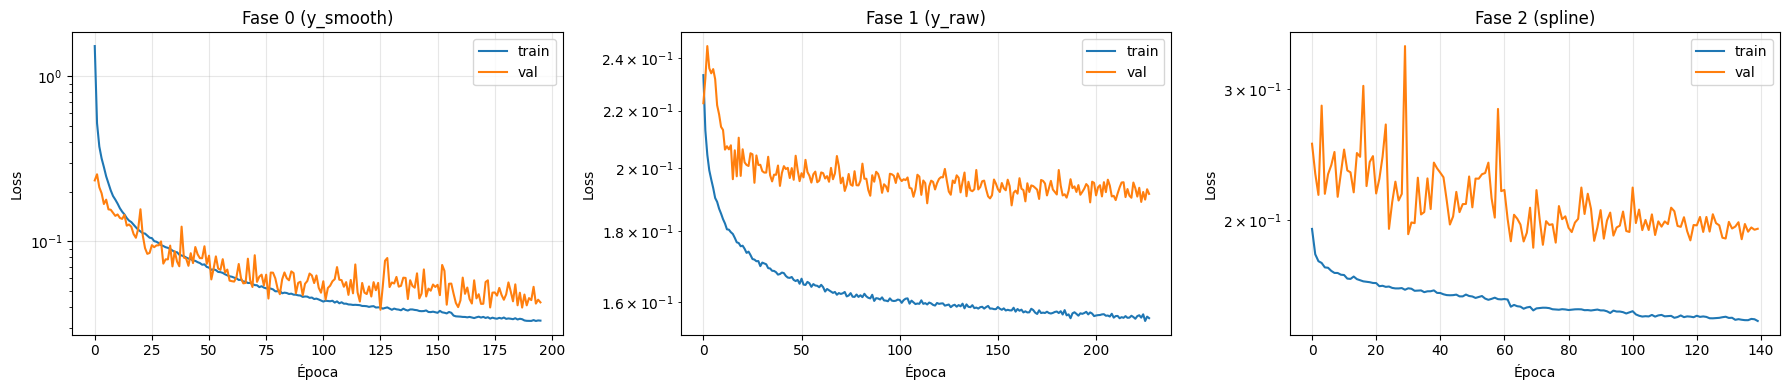

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, hist, name in zip(axes,
                           [hist_p0, hist_p1, hist_p2],
                           ["Fase 0 (y_smooth)", "Fase 1 (y_raw)", "Fase 2 (spline)"]):
    ax.plot(hist["train_loss"], label="train")
    ax.plot(hist["val_loss"],   label="val")
    ax.set_title(name)
    ax.set_xlabel("Época")
    ax.set_ylabel("Loss")
    ax.set_yscale("log")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/training_curves_curriculum.png", dpi=150)
plt.show()

# Evolución final

In [17]:
model_p2.load_state_dict(torch.load(CKPT_P2, map_location=device))
model_p2.eval()

all_y_hat, all_y_true, all_eps, all_mask = [], [], [], []
with torch.no_grad():
    for batch in val_loader:
        batch  = {k: v.to(device) for k, v in batch.items()}
        y_hat, eps_hat, _ = model_p2(batch, return_parts=True)
        y_true   = torch.stack([batch[f"log_liters_{i}"] for i in range(n_upcs)], dim=1)
        obs_mask = torch.stack([batch[f"obs_mask_{i}"]   for i in range(n_upcs)], dim=1)
        all_y_hat.append(y_hat.cpu())
        all_y_true.append(y_true.cpu())
        all_eps.append(eps_hat.cpu())
        all_mask.append(obs_mask.cpu())

y_hat  = torch.cat(all_y_hat)
y_true = torch.cat(all_y_true)
eps    = torch.cat(all_eps)
mask   = torch.cat(all_mask)

mae = ((y_hat - y_true).abs() * mask).sum() / mask.sum()
print(f"Val MAE (final): {mae:.4f}")
print(f"Elasticidad media: {eps[mask.bool()].mean():.3f}")
print(f"Elasticidad mediana: {eps[mask.bool()].median():.3f}")
print(f"% elasticidades negativas: {(eps[mask.bool()] < 0).float().mean()*100:.1f}%")

Val MAE (final): 0.4817
Elasticidad media: -2.542
Elasticidad mediana: -2.005
% elasticidades negativas: 100.0%


# Visualuzacion

/tmp/ipykernel_42453/3466134119.py:56: RuntimeWarning: Mean of empty slice.
  label=f'Prod {i} (media={eps_np[m, i].mean():.2f})'
/home/thebigmonster/Github/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


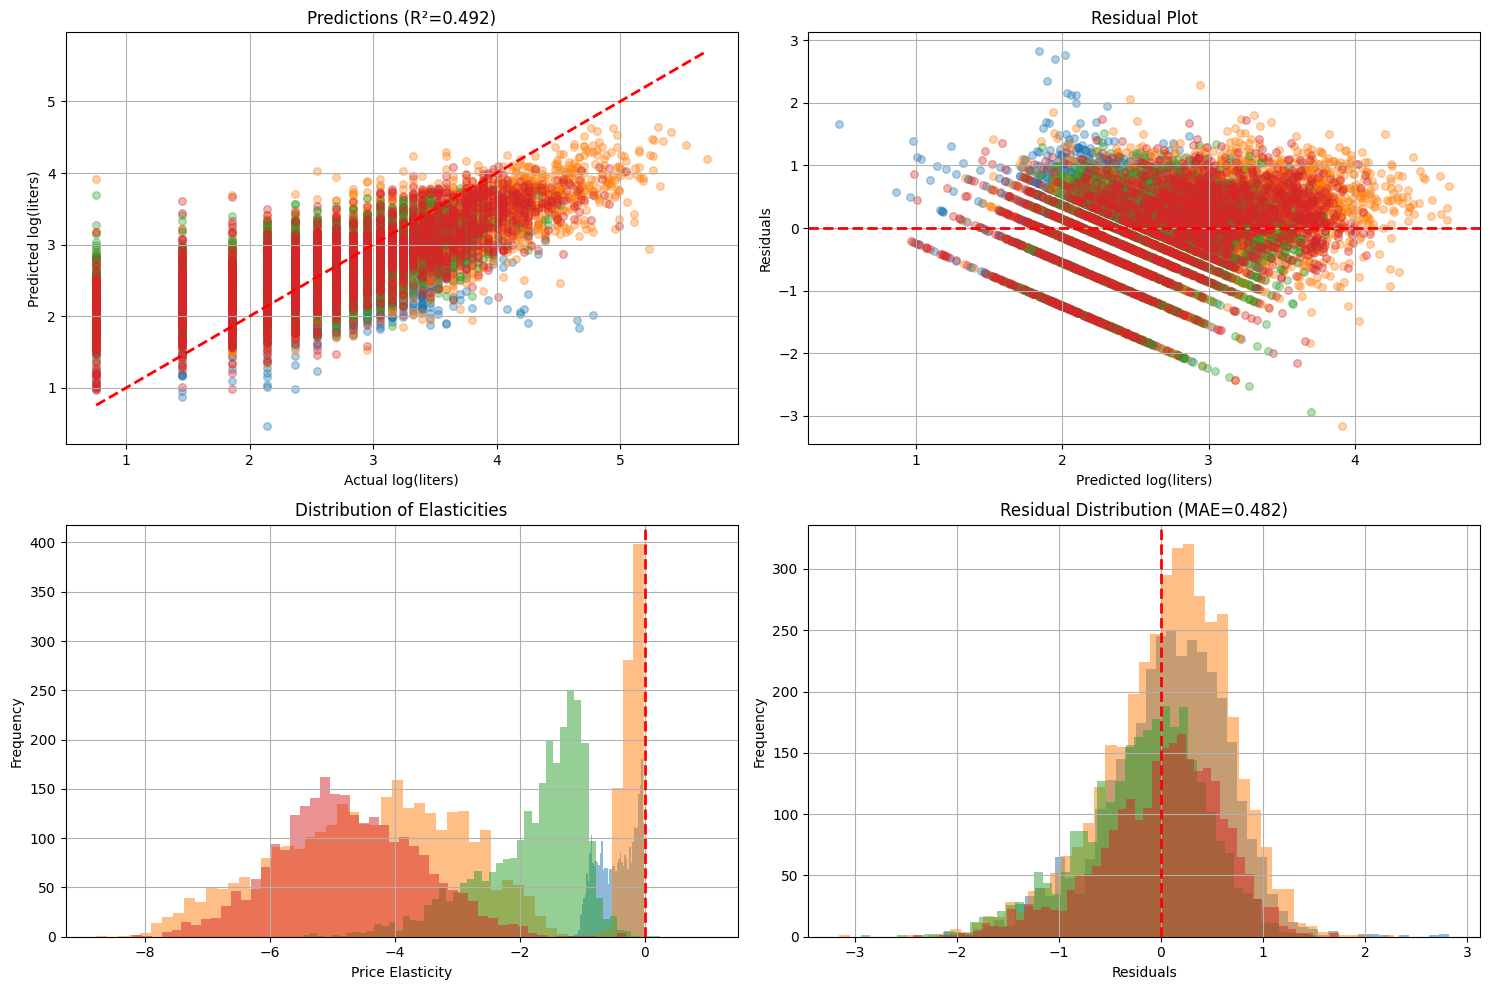


✓ Pipeline completado exitosamente


In [18]:
point_size = 30
point_alpha = 0.35

# Reconstruir desde las listas acumuladas (shapes garantizadas correctas)
preds_np   = torch.cat(all_y_hat).cpu().numpy()
targets_np = torch.cat(all_y_true).cpu().numpy()
mask_np    = torch.cat(all_mask).cpu().bool().numpy()
eps_np     = torch.cat(all_eps).cpu().numpy()

# R² sobre todos los valores observados
r2 = r2_score(targets_np[mask_np], preds_np[mask_np])
mae_val = float(((torch.cat(all_y_hat) - torch.cat(all_y_true)).abs() * torch.cat(all_mask)).sum() / torch.cat(all_mask).sum())

n = n_upcs
colors = [plt.cm.tab10(i) for i in range(n)]
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Predicted vs Actual — por producto
for i in range(n):
    m = mask_np[:, i]
    axes[0, 0].scatter(
        targets_np[m, i], preds_np[m, i],
        alpha=point_alpha, s=point_size,
        color=colors[i], label=f'Prod {i}'
    )
axes[0, 0].plot(
    [targets_np[mask_np].min(), targets_np[mask_np].max()],
    [targets_np[mask_np].min(), targets_np[mask_np].max()], 'r--', lw=2
)
axes[0, 0].set_xlabel('Actual log(liters)')
axes[0, 0].set_ylabel('Predicted log(liters)')
axes[0, 0].set_title(f'Predictions (R²={r2:.3f})')
axes[0, 0].grid(True)

# Residual Plot — por producto
residuals_np = targets_np - preds_np
for i in range(n):
    m = mask_np[:, i]
    axes[0, 1].scatter(
        preds_np[m, i], residuals_np[m, i],
        alpha=point_alpha, s=point_size,
        color=colors[i], label=f'Prod {i}'
    )
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted log(liters)')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].grid(True)

# Distribution of Elasticities — por producto
for i in range(n):
    m = mask_np[:, i]
    axes[1, 0].hist(
        eps_np[m, i], bins=50, alpha=0.5,
        color=colors[i],
        label=f'Prod {i} (media={eps_np[m, i].mean():.2f})'
    )
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Price Elasticity')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Elasticities')
axes[1, 0].grid(True)

# Residual Distribution — por producto
for i in range(n):
    m = mask_np[:, i]
    axes[1, 1].hist(
        residuals_np[m, i], bins=50, alpha=0.5,
        color=colors[i], label=f'Prod {i}'
    )
axes[1, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title(f'Residual Distribution (MAE={mae_val:.3f})')
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('../results/evaluation_plots.png', dpi=150)
plt.show()

print("\n✓ Pipeline completado exitosamente")

# Save

In [19]:
model_p2.load_state_dict(torch.load(CKPT_P2, map_location=device))
model_p2.eval()

rows = []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        # tienda (índice y código original)
        store_idx  = batch["store_code"].cpu().numpy()               # (B,)
        store_code = np.array(store_cats)[store_idx]                 # (B,)

        # máscara de observación por producto
        obs_mask = torch.stack(
            [batch[f"obs_mask_{i}"] for i in range(n_upcs)], dim=1
        )  # (B, n)

        # matriz de elasticidades (own + cross)
        y_hat, eps_hat, aux = model_p2.run(batch, return_parts=True, compute_E=True)
        E         = aux["E"].cpu().numpy()                           # (B, n, n)
        mask_np   = obs_mask.cpu().numpy().astype(bool)              # (B, n)
        y_true_np = torch.stack(
            [batch[f"log_liters_{i}"] for i in range(n_upcs)], dim=1
        ).cpu().numpy()                                              # (B, n)
        y_hat_np  = y_hat.cpu().numpy()                              # (B, n)

        B         = E.shape[0]
        upc_names = np.array(mp_builder.selected_upcs)

        for b in range(B):
            sc = store_code[b]
            for i in range(n_upcs):
                if not mask_np[b, i]:
                    continue
                for j in range(n_upcs):
                    if not mask_np[b, j]:
                        continue
                    rows.append({
                        "store_code": sc,
                        "upc_i":      upc_names[i],
                        "upc_j":      upc_names[j],
                        "tipo":       "own" if i == j else "cross",
                        "E":          E[b, i, j],
                        "y_true_i":   y_true_np[b, i],
                        "y_hat_i":    y_hat_np[b, i],
                    })

df_E_store = pd.DataFrame(rows)

# Resumen rápido (igual que antes)
agg = df_E_store.groupby(["store_code", "upc_i", "upc_j", "tipo"]).agg(
    E_mean = ("E", "mean"),
    n_obs  = ("E", "size"),
).reset_index()

print("=== Own-price por tienda ===")
print(
    agg[agg["tipo"] == "own"]
    [["store_code", "upc_i", "E_mean", "n_obs"]]
    .sort_values(["store_code", "upc_i"])
    .to_string(index=False)
)

print("\n=== Cross-price por tienda (|E_mean| > 0.05) ===")
cross = agg[
    (agg["tipo"] == "cross") & (agg["E_mean"].abs() > 0.05)
].sort_values("E_mean", key=abs, ascending=False)
print(cross.to_string(index=False))

=== Own-price por tienda ===
 store_code      upc_i    E_mean  n_obs
          5 7289000011 -1.708493     14
          8 1820000784 -1.772810     61
          8 3410010505 -0.397139     61
          8 7289000011 -2.777509     61
          9 1820000784 -1.698579     52
          9 3410010505 -0.524650     61
          9 7289000011 -3.354437     61
          9 8248812345 -4.083750     60
         12 1820000784 -1.502912     61
         12 3410010505 -0.151769     50
         12 7289000011 -4.424655     61
         12 8248812345 -4.303003     61
         14 1820000784 -2.334581     61
         14 3410010505 -0.178637     61
         14 7289000011 -3.706756     61
         14 8248812345 -5.136596     60
         18 1820000784 -1.876933     61
         18 3410010505 -0.373131     60
         18 7289000011 -4.018466     61
         18 8248812345 -4.793515     61
         21 3410010505 -0.735840     54
         21 7289000011 -2.675839     61
         32 1820000784 -2.006475     61
         32

In [20]:
def agg_elasticity(g):
    n       = len(g)
    mean_E  = g["E"].mean()
    se      = g["E"].std(ddof=1) / np.sqrt(n) if n > 1 else np.nan
    ci_low  = mean_E - 1.96 * se if n > 1 else np.nan
    ci_high = mean_E + 1.96 * se if n > 1 else np.nan

    if n > 1:
        ss_res = ((g["y_true_i"] - g["y_hat_i"]) ** 2).sum()
        ss_tot = ((g["y_true_i"] - g["y_true_i"].mean()) ** 2).sum()
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    else:
        r2 = np.nan

    return pd.Series({
        "elasticity":         mean_E,
        "elasticity_se":      se,
        "elasticity_ci_low":  ci_low,
        "elasticity_ci_high": ci_high,
        "r2_val":          r2,
        "n_obs":              n,
    })

# ── Own-price: store_code x upc_code ─────────────────────────────────────────
own_df = (
    df_E_store[df_E_store["tipo"] == "own"]
    .groupby(["store_code", "upc_i"], as_index=False)
    .apply(agg_elasticity, include_groups=False)
    .rename(columns={"upc_i": "upc_code"})
)
own_df.to_csv("../data/nn_elasticities_store_upc.csv", index=False)
print(f"Own guardado: {own_df.shape[0]} filas → nn_elasticities_store_upc.csv")

# ── Cross-price: store_code x upc_i x upc_j ──────────────────────────────────
cross_df = (
    df_E_store[df_E_store["tipo"] == "cross"]
    .groupby(["store_code", "upc_i", "upc_j"], as_index=False)
    .apply(agg_elasticity, include_groups=False)
)
cross_df.to_csv("../data/nn_cross_elasticities_store_upc.csv", index=False)
print(f"Cross guardado: {cross_df.shape[0]} filas → nn_cross_elasticities_store_upc.csv")

Own guardado: 217 filas → nn_elasticities_store_upc.csv
Cross guardado: 544 filas → nn_cross_elasticities_store_upc.csv
